<a href="https://colab.research.google.com/github/mesata/Facial-Expression-Recognition-/blob/main/data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

# 1. Securely load your Kaggle Token from Colab Secrets
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mesatia (mesatia-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip -d ./data
!ls ./data

100% 285M/285M [00:01<00:00, 150MB/s]

example_submission.csv	fer2013.tar.gz	icml_face_data.csv  test.csv  train.csv


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('./data/train.csv')

print("Dataset shape ")
print(df.shape)
print("columns:")
print(df.columns.tolist())

Dataset shape 
(28709, 2)
columns:
['emotion', 'pixels']


ემოციების განაწილება


/tmp/ipykernel_521/2436673662.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion_label', order=emotion_mapping.values(), palette='PuRd')


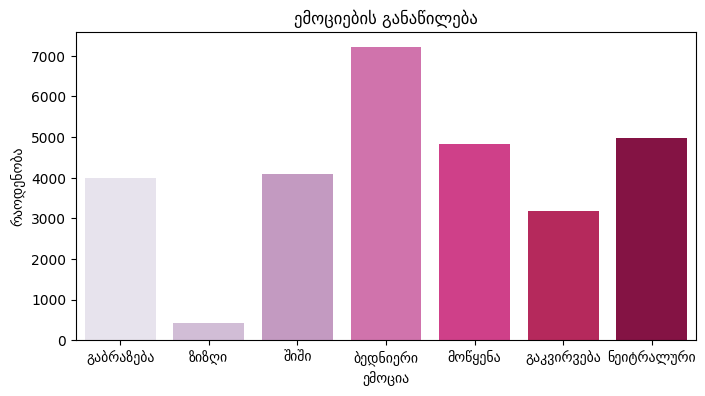


 ზუსტი რაოდენობები
emotion_label
ბედნიერი      7215
ნეიტრალური    4965
მოწყენა       4830
შიში          4097
გაბრაზება     3995
გაკვირვება    3171
ზიზღი          436
Name: count, dtype: int64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("ემოციების განაწილება")

emotion_mapping = {
    0: 'გაბრაზება', 1: 'ზიზღი', 2: 'შიში',
    3: 'ბედნიერი', 4: 'მოწყენა', 5: 'გაკვირვება', 6: 'ნეიტრალური'
}
df['emotion_label'] = df['emotion'].map(emotion_mapping)

# 🌸
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='emotion_label', order=emotion_mapping.values(), palette='PuRd')
plt.title('ემოციების განაწილება')
plt.ylabel('რაოდენობა')
plt.xlabel('ემოცია')
plt.show()

print("\n ზუსტი რაოდენობები")
print(df['emotion_label'].value_counts())

In [30]:
import numpy as np
from sklearn.model_selection import train_test_split

pixel_list = []
for pixel_str in df['pixels']:
    arr = np.fromstring(pixel_str, sep=' ', dtype=np.float32) / 255.0
    pixel_list.append(arr.reshape(48, 48))



საბოლოო მასივები: 
X_train (სავარჯიშო სურათები): (24402, 48, 48), y_train: (24402,)
X_val   (სავალიდაციო სურათები): (4307, 48, 48), y_val: (4307,)


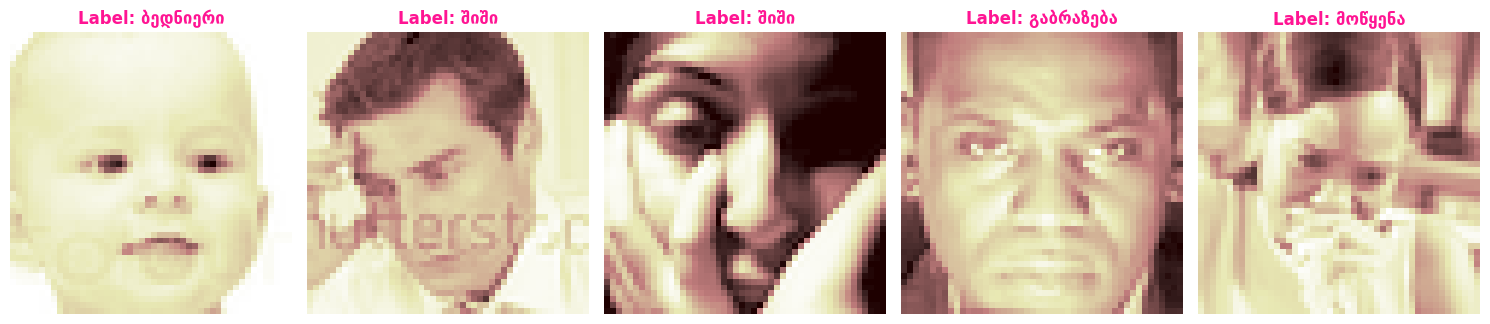

In [34]:
X_all = np.array(pixel_list)
y_all = df['emotion'].values

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)

print("საბოლოო მასივები: ")
print(f"X_train (სავარჯიშო სურათები): {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val   (სავალიდაციო სურათები): {X_val.shape}, y_val: {y_val.shape}")

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
random_indices = np.random.randint(0, len(X_train), size=5)

for i, idx in enumerate(random_indices):
    axes[i].imshow(X_train[idx], cmap='pink')
    axes[i].set_title(f"Label: {emotion_mapping[y_train[idx]]}", color='deeppink', fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


class_counts = np.bincount(y_train)
total_samples = len(y_train)
class_weights = total_samples / (len(class_counts) * class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print("weights: ")
for i, weight in enumerate(class_weights):
    print(f"Class {i}: {weight:.4f}")


weights: 
Class 0: 1.0265
Class 1: 9.3962
Class 2: 1.0011
Class 3: 0.5684
Class 4: 0.8492
Class 5: 1.2935
Class 6: 0.8261


In [36]:

X_train_pt = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_pt = torch.tensor(y_train, dtype=torch.long)

X_val_pt = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
y_val_pt = torch.tensor(y_val, dtype=torch.long)

X_test_pt = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_pt = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_pt, y_train_pt)
val_dataset = TensorDataset(X_val_pt, y_val_pt)
test_dataset = TensorDataset(X_test_pt, y_test_pt)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\n PyTorch DataLoaders created")
print(f"Train Batches: {len(train_loader)}, Validation Batches: {len(val_loader)}")


 PyTorch DataLoaders created
Train Batches: 382, Validation Batches: 68


In [22]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/fer2013_processed', exist_ok=True)
print(" folder is initialized")

Mounted at /content/drive
 folder is initialized


In [37]:
import numpy as np

np.save('/content/drive/MyDrive/fer2013_processed/X_train.npy', X_train)
np.save('/content/drive/MyDrive/fer2013_processed/y_train.npy', y_train)

np.save('/content/drive/MyDrive/fer2013_processed/X_val.npy', X_val)
np.save('/content/drive/MyDrive/fer2013_processed/y_val.npy', y_val)

np.save('/content/drive/MyDrive/fer2013_processed/X_test.npy', X_test)
np.save('/content/drive/MyDrive/fer2013_processed/y_test.npy', y_test)

print("saved")

saved
